In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\Public\Documents\Axel\libertadores26-data\matchStats\csv\fotmob_match_stats.csv')
df.tail()

,matchId,matchRound,homeTeamName,homeTeamid,awayTeamName,awayTeamid,home_goals,away_goals,ball_possession_home,ball_possession_away,...,ground_duels_won_home,ground_duels_won_away,aerial_won_home,aerial_won_away,dribbles_succeeded_home,dribbles_succeeded_away,yellow_cards_home,yellow_cards_away,red_cards_home,red_cards_away
90,5261485,Group Stage - Round 6,Fluminense,9863,Deportivo La Guaira,176496,3,1,56,44,...,35 (48%),38 (52%),11 (73%),4 (27%),11 (65%),10 (63%),0,0,0,0
91,5261508,Group Stage - Round 6,Cerro Porteno,6295,Sporting Cristal,1848,2,0,51,49,...,37 (53%),33 (47%),16 (70%),7 (30%),6 (43%),5 (50%),0,0,0,0
92,5261509,Group Stage - Round 6,Palmeiras,10283,Junior FC,2254,4,1,49,51,...,55 (65%),30 (35%),6 (55%),5 (45%),15 (60%),8 (40%),0,0,0,0
93,5261542,Group Stage - Round 6,Boca Juniors,10077,Universidad Catolica,6458,0,1,71,29,...,46 (58%),34 (43%),23 (59%),16 (41%),13 (46%),2 (25%),0,0,0,0
94,5261543,Group Stage - Round 6,Cruzeiro,9781,Barcelona SC,6453,4,0,59,41,...,32 (53%),28 (47%),10 (53%),9 (47%),7 (58%),6 (100%),0,0,0,0


In [4]:
# TEST

import pandas as pd

# Create a dataframe with home teams and their goals
home_df = df[['homeTeamName', 'home_goals']].rename(
    columns={
        'homeTeamName': 'teamName',
        'home_goals': 'goals'
    }
)

# Create a dataframe with away teams and their goals
away_df = df[['awayTeamName', 'away_goals']].rename(
    columns={
        'awayTeamName': 'teamName',
        'away_goals': 'goals'
    }
)

# Stack both dataframes together
teams_goals = pd.concat([home_df, away_df], ignore_index=True)

# Sum goals by team
result = (
    teams_goals
    .groupby('teamName', as_index=False)['goals']
    .sum()
    .sort_values('goals', ascending=False)
)

print(result)

                     teamName  goals
16    Independiente Rivadavia     15
13                   Flamengo     11
17    Independiente del Valle     11
24                  Palmeiras     10
25            Rosario Central      9
6      Club Atletico Platense      8
8                 Corinthians      8
7              Coquimbo Unido      8
9                    Cruzeiro      8
19               LDU de Quito      8
29       Universidad Catolica      8
22                   Mirassol      7
23                   Nacional      7
14                 Fluminense      7
0                Always Ready      7
30        Universidad Central      7
28                     Tolima      7
2                Boca Juniors      6
27           Sporting Cristal      6
15     Independiente Medellin      6
4               Cerro Porteno      6
3                     Bolivar      6
11        Deportivo La Guaira      6
12                Estudiantes      6
26                   Santa Fe      6
18                  Junior FC      5
3

In [3]:
# Promedio de posesión por equipo como local
promedio_poss_local = df.groupby('homeTeamName')['ball_possession_home'].mean().reset_index()
promedio_poss_local

,homeTeamName,ball_possession_home
0,Always Ready,58.666667
1,Barcelona SC,55.000000
2,Boca Juniors,62.666667
3,Bolivar,62.333333
4,Cerro Porteno,43.666667
5,Club Atletico Penarol,50.000000
6,Club Atletico Platense,54.666667
7,Coquimbo Unido,51.000000
8,Corinthians,73.666667
9,Cruzeiro,61.666667


In [5]:
# Promedio de posesión por equipo como local
promedio_poss_local = df.groupby('homeTeamName')['ball_possession_home'].mean().reset_index()
promedio_poss_local.columns = ['Equipo', 'Promedio_Posesion_Local']
promedio_poss_local = promedio_poss_local.sort_values('Promedio_Posesion_Local', ascending=False)

# Ver el equipo con mayor promedio
equipo_max_promedio = promedio_poss_local.iloc[0]
print(f"Equipo con mayor promedio de posesión como local: {equipo_max_promedio['Equipo']} - {equipo_max_promedio['Promedio_Posesion_Local']:.2f}%")

Equipo con mayor promedio de posesión como local: Corinthians - 73.67%


In [3]:
# Pomedio de posesión por equipo local
resultado = df.groupby('homeTeamName').agg({
    'ball_possession_home': ['mean', 'count', 'sum']
}).reset_index()

# Ordenar de mayor a menor por la columna 'mean'
resultado = resultado.sort_values(('ball_possession_home', 'mean'), ascending=False)

resultado

homeTeamName ball_possession_home           
                                              mean count  sum
8                 Corinthians            73.666667     3  221
14                 Fluminense            67.000000     3  201
28                     Tolima            65.333333     3  196
13                   Flamengo            64.666667     3  194
15     Independiente Medellin            63.500000     2  127
2                Boca Juniors            62.666667     3  188
24                  Palmeiras            62.666667     3  188
3                     Bolivar            62.333333     3  187
17    Independiente del Valle            62.000000     3  186
9                    Cruzeiro            61.666667     3  185
12                Estudiantes            60.000000     3  180
0                Always Ready            58.666667     3  176
25            Rosario Central            58.000000     3  174
10                   Cusco FC            57.666667     3  173
29       Universidad Catolica            57.666667     3  173
31  Universitario de Deportes            57.333333     3  172
20                      Lanus            56.000000     3  168
1                Barcelona SC            55.000000     3  165
6      Club Atletico Platense            54.666667     3  164
18                  Junior FC            53.000000     3  159
27           Sporting Cristal            53.000000     3  159
7              Coquimbo Unido            51.000000     3  153
19               LDU de Quito            50.666667     3  152
5       Club Atletico Penarol            50.000000     3  150
26                   Santa Fe            50.000000     3  150
22                   Mirassol            47.666667     3  143
11        Deportivo La Guaira            46.333333     3  139
4               Cerro Porteno            43.666667     3  131
21                   Libertad            43.666667     3  131
23                   Nacional            40.666667     3  122
16    Independiente Rivadavia            38.333333     3  115
30        Universidad Central            38.333333     3  115

In [24]:
# Pomedio de posesión por equipo local into a DATA FRAME
h_result = (df.groupby('homeTeamName')['ball_possession_home']
             .agg(['mean', 'count', 'sum'])
             .reset_index()
             .sort_values('mean', ascending=False)
             .rename(columns={
                 'mean': 'mean_possession',
                 'count': 'count_games', 
                 'sum': 'sum_possession'
             }))

h_result

,homeTeamName,mean_possession,count_games,sum_possession
8,Corinthians,73.666667,3,221
14,Fluminense,67.000000,3,201
28,Tolima,65.333333,3,196
13,Flamengo,64.666667,3,194
15,Independiente Medellin,63.500000,2,127
2,Boca Juniors,62.666667,3,188
24,Palmeiras,62.666667,3,188
3,Bolivar,62.333333,3,187
17,Independiente del Valle,62.000000,3,186
9,Cruzeiro,61.666667,3,185


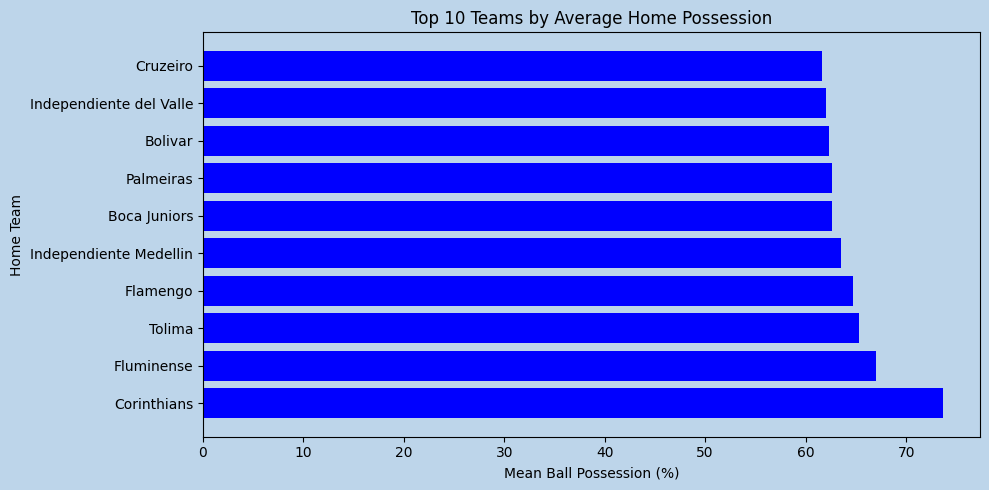

In [45]:
# BAR CHART home teams possession
h_top10 = h_result.head(10)

plt.figure(figsize=(10, 5), facecolor="#BDD5EA")

ax = plt.gca()
ax.set_facecolor("#BDD5EA")

plt.barh(h_top10.homeTeamName, h_top10.mean_possession, color='blue')
plt.xlabel('Mean Ball Possession (%)')
plt.ylabel('Home Team')
plt.title('Top 10 Teams by Average Home Possession')
plt.tight_layout()
plt.show()

In [7]:
# Pomedio de posesión por equipo visitante
resultado = df.groupby('awayTeamName').agg({
    'ball_possession_away': ['mean', 'count', 'sum']
}).reset_index()

# Ordenar de mayor a menor por la columna 'mean'
resultado = resultado.sort_values(('ball_possession_away', 'mean'), ascending=False)

resultado

awayTeamName ball_possession_away           
                                              mean count  sum
14                 Fluminense            62.333333     3  187
24                  Palmeiras            60.333333     3  181
28                     Tolima            59.333333     3  178
25            Rosario Central            56.333333     3  169
8                 Corinthians            55.666667     3  167
17    Independiente del Valle            55.333333     3  166
22                   Mirassol            54.000000     3  162
18                  Junior FC            49.666667     3  149
13                   Flamengo            49.000000     2   98
2                Boca Juniors            48.666667     3  146
21                   Libertad            48.333333     3  145
3                     Bolivar            47.333333     3  142
9                    Cruzeiro            46.333333     3  139
0                Always Ready            45.333333     3  136
27           Sporting Cristal            44.666667     3  134
31  Universitario de Deportes            44.666667     3  134
20                      Lanus            44.000000     3  132
7              Coquimbo Unido            43.666667     3  131
19               LDU de Quito            43.666667     3  131
26                   Santa Fe            40.666667     3  122
11        Deportivo La Guaira            40.000000     3  120
6      Club Atletico Platense            39.000000     3  117
30        Universidad Central            38.000000     3  114
23                   Nacional            38.000000     3  114
10                   Cusco FC            37.666667     3  113
5       Club Atletico Penarol            36.333333     3  109
16    Independiente Rivadavia            36.333333     3  109
12                Estudiantes            36.000000     3  108
15     Independiente Medellin            35.666667     3  107
1                Barcelona SC            34.000000     3  102
29       Universidad Catolica            34.000000     3  102
4               Cerro Porteno            33.000000     3   99

In [11]:
# Pomedio de posesión por equipo visitante into a DATA FRAME
resultado = (df.groupby('awayTeamName')['ball_possession_away']
             .agg(['mean', 'count', 'sum'])
             .reset_index()
             .sort_values('mean', ascending=False)
             .rename(columns={
                 'mean': 'mean_possession',
                 'count': 'count_games', 
                 'sum': 'sum_possession'
             }))

resultado

,awayTeamName,mean_possession,count_games,sum_possession
14,Fluminense,62.333333,3,187
24,Palmeiras,60.333333,3,181
28,Tolima,59.333333,3,178
25,Rosario Central,56.333333,3,169
8,Corinthians,55.666667,3,167
17,Independiente del Valle,55.333333,3,166
22,Mirassol,54.000000,3,162
18,Junior FC,49.666667,3,149
13,Flamengo,49.000000,2,98
2,Boca Juniors,48.666667,3,146


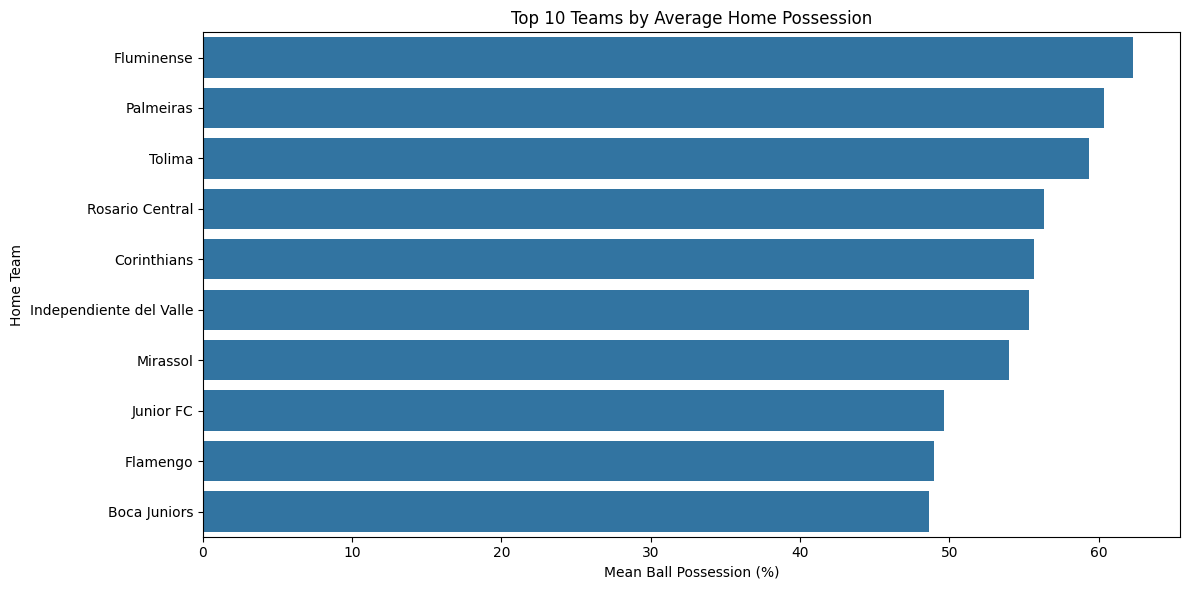

In [13]:
# Example visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 teams by mean possession
top10 = resultado.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top10, x='mean_possession', y='awayTeamName')
plt.xlabel('Mean Ball Possession (%)')
plt.ylabel('Home Team')
plt.title('Top 10 Teams by Average Home Possession')
plt.tight_layout()
plt.show()